# Employee Attrition Prediction using Machine Learning

### Name: Vaishnavi Vaishnav

### Internship: Xylofy AI

### Week: 2

### Project Title:
Employee Attrition Prediction using Machine Learning

Project Objective:

This project aims to analyze employee attrition data, identify the key factors affecting employee resignation, build machine learning models to predict attrition, compare model performance, and provide HR recommendations for improving employee retention.

1.Data Loading
Description:

 This section loads the employee attrition dataset using the Pandas library. The first five records are displayed to verify that the dataset has been imported successfully.

In [ ]:
import pandas as pd

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Observation:

The dataset has been loaded successfully. The first five records show employee details such as Age, Attrition, Business Travel, Department, and Distance From Home. This confirms that the dataset is ready for further analysis.

Dataset Overview
Description:

This section analyzes the dataset by checking its shape, target variable distribution, attrition percentage, and the number of numerical and categorical features.

In [ ]:
print("Shape of Dataset:", df.shape)

print("\nTarget Column:")
print(df['Attrition'].value_counts())

print("\nAttrition Percentage:")
print(df['Attrition'].value_counts(normalize=True)*100)

num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("\nNumeric Columns:", len(num_cols))
print("Categorical Columns:", len(cat_cols))

Shape of Dataset: (1470, 35)

Target Column:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Percentage:
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

Numeric Columns: 26
Categorical Columns: 9


Observation:



*   The dataset contains 1470 rows and 35 columns.

*  The target variable Attrition is imbalanced, with 83.88% employees staying and 16.12% employees leaving the company.

*   The dataset contains 26 numerical and 9 categorical features.
*   This information helps understand the dataset before performing preprocessing and model building.









2.Data Cleaning & Preprocessing
Description:

This section checks for missing values, removes unnecessary columns, and converts the target variable (Attrition) into numerical format for machine learning models.

In [ ]:
# Check missing values
print(df.isnull().sum())

# Drop unnecessary columns
df = df.drop(['EmployeeNumber','Over18','StandardHours'], axis=1)

# Convert Attrition column into 0 and 1
df['Attrition'] = df['Attrition'].map({'Yes':1,'No':0})

print("\nNew Shape:")
print(df.shape)

df.head()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,3,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,4,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,1,...,3,4,1,6,3,3,2,2,2,2


Observation:
* No missing values were found in the dataset.
* Unnecessary columns (EmployeeNumber, Over18, StandardHours) were removed.

*  The Attrition column was converted into numerical format (Yes = 1, No = 0).
* The cleaned dataset is now ready for exploratory data analysis and model building.





3.Exploratory Data Analysis (EDA)
Description:

This section explores the relationship between employee attrition and different factors such as department, job role, monthly income, work-life balance, and years at the company. These visualizations help identify important patterns before building machine learning models.

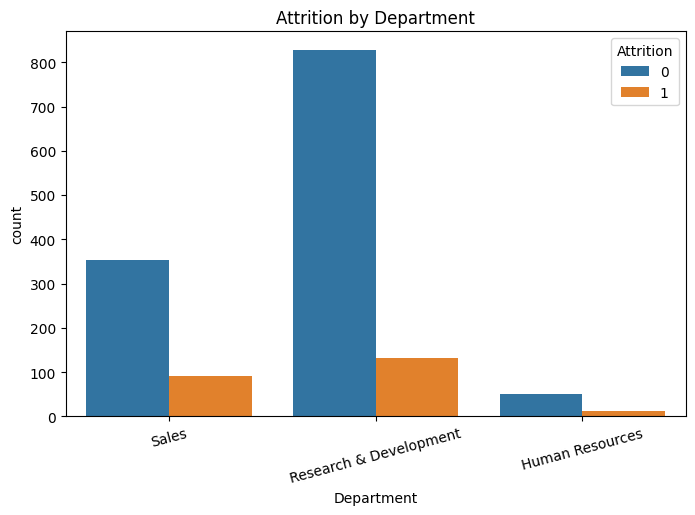

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x='Department', hue='Attrition', data=df)

plt.title('Attrition by Department')
plt.xticks(rotation=15)
plt.show()

Observation:



*   Research & Development department has the highest number of employees.
*   The highest number of employee resignations is also observed in the Research & Development department.



*   Sales department has the second-highest attrition.
*  Human Resources has the lowest number of employees and employee exits.





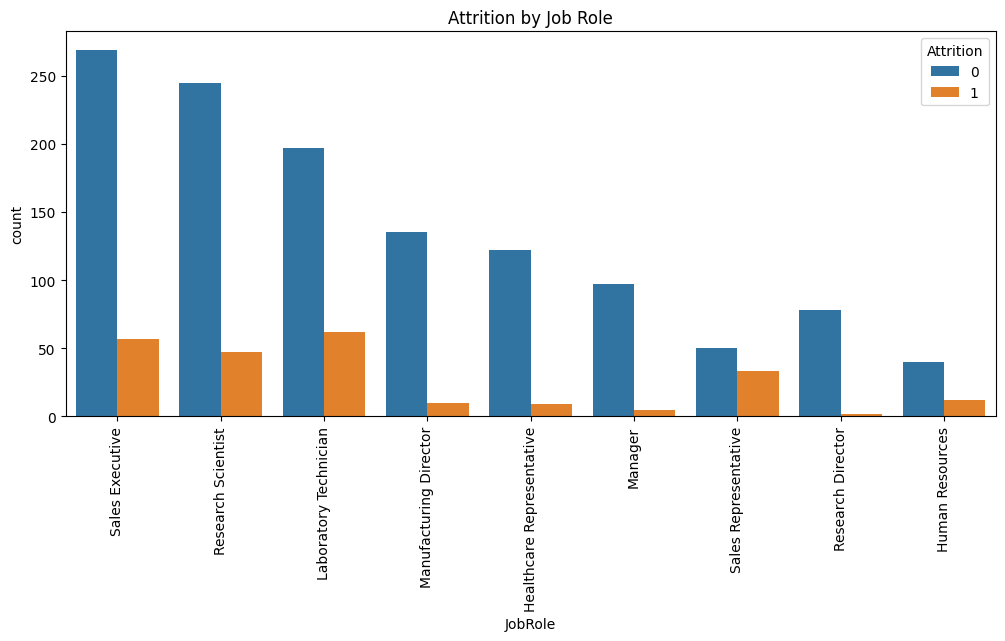

In [ ]:
plt.figure(figsize=(12,5))
sns.countplot(x='JobRole', hue='Attrition', data=df)

plt.title('Attrition by Job Role')
plt.xticks(rotation=90)
plt.show()

Observation:


*   Sales Representatives show the highest employee attrition among all job roles.


*   Laboratory Technicians also have a relatively high number of employee exits.
*   Research Scientists have a moderate level of attrition.


*   Manager and Research Director roles show the lowest attrition.
*   These findings indicate that HR should focus retention strategies on Sales Representatives and Laboratory Technicians.





Monthly Income vs Attrition Description:

This box plot compares the monthly income of employees who stayed in the company and those who left. It helps identify whether salary has an impact on employee attrition.

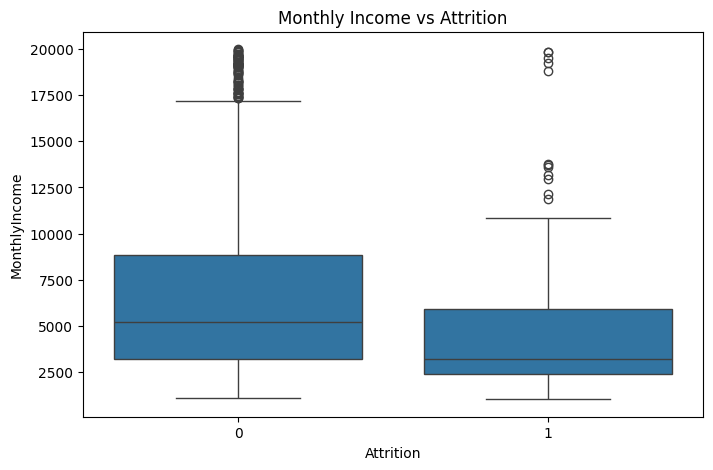

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)

plt.title('Monthly Income vs Attrition')
plt.show()

Observation:


*   Employees who left the company (Attrition = 1) generally have lower monthly incomes than those who stayed.
*   Employees with higher monthly incomes are less likely to leave the company.


*   A few high-income employees also resigned, but they are outliers and represent a small number of cases.
*   This suggests that salary is an important factor influencing employee attrition, although it is not the only reason.




Description:

Work-Life Balance vs Attrition Description:

This chart compares employee attrition across different work-life balance levels. It helps understand whether work-life balance has an impact on employees leaving the company.

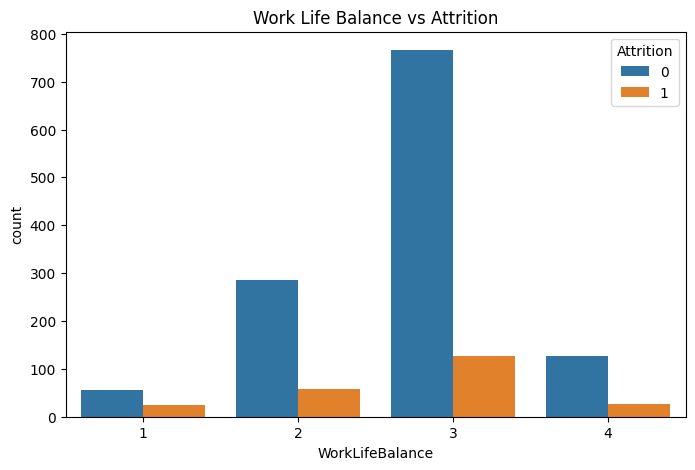

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='WorkLifeBalance', hue='Attrition', data=df)

plt.title('Work Life Balance vs Attrition')
plt.show()

Observation:

Employees with poor work-life balance show a relatively higher attrition rate.

* Employees with poor work-life balance show a relatively higher attrition rate.
  
* Employees with better work-life balance are more likely to stay in the company.  


*   Improving work-life balance may help reduce employee attrition.
*   HR should focus on employee well-being and flexible work policies to improve retention.












Description:

Years at Company vs Attrition Description:

This histogram shows the relationship between the number of years employees have worked at the company and employee attrition. It helps identify during which stage of employment employees are more likely to leave.

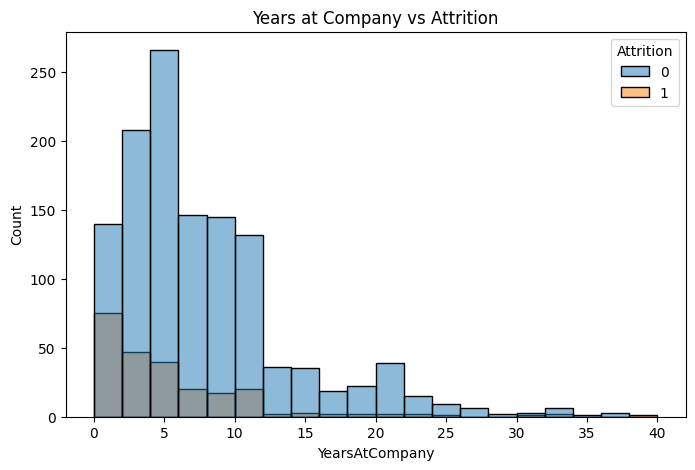

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='YearsAtCompany', hue='Attrition', bins=20)

plt.title('Years at Company vs Attrition')
plt.show()

Observation:


*   Most employee resignations occur during the first few years of employment.
*   Employees who stay longer at the company are less likely to leave.
Attrition decreases as the years at the company increase.

  
*   This suggests that new employees should receive better onboarding, mentoring, and career support to improve retention.


Business Insights:

1. Research & Development department has the highest number of employee exits.
2. Sales Representatives and Laboratory Technicians show relatively higher attrition.
3. Employees with lower monthly income are more likely to leave.
4. Poor work-life balance is associated with higher attrition.
5. Most employee exits occur during the initial years of employment.

Model Preparation Description:

This section prepares the dataset for machine learning by separating the target variable (Attrition) from the input features. Numerical features are standardized, categorical features are one-hot encoded, and the dataset is split into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = df.drop('Attrition', axis=1)
y = df['Attrition']

categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1176, 31)
Testing Data Shape: (294, 31)


Observation:



*   The dataset was successfully prepared for machine learning.



*   Numerical features were standardized, and categorical features were converted using one-hot encoding.


*   The data was divided into training and testing sets to evaluate model performance fairly.
*   This preprocessing step improves the accuracy and reliability of the machine learning models.


4.Model Building and Training Description

This section trains three machine learning models—Logistic Regression, Random Forest, and Gradient Boosting—using the prepared employee attrition dataset. These models are trained to predict whether an employee is likely to leave the company.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

log_model = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000))
])

rf_model = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42))
])

gb_model = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingClassifier())
])

log_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

print("All models trained successfully!")

All models trained successfully!


Observation:



*   All three models were trained successfully.

*   The dataset was split into training and testing sets.
*   The models are ready for performance evaluation and comparison.

5.Model Evaluation

This section evaluates the trained models using Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and ROC-AUC Score to determine the best-performing model.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

for name, model in models.items():
    y_pred = model.predict(X_test)

    print("\n" + "="*50)
    print(name)
    print("="*50)

    print(classification_report(y_test, y_pred))

    roc = roc_auc_score(y_test, y_pred)
    print("ROC-AUC Score:", roc)


Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.35      0.64      0.45        47

    accuracy                           0.75       294
   macro avg       0.63      0.71      0.65       294
weighted avg       0.83      0.75      0.78       294

ROC-AUC Score: 0.705788612283573

Random Forest
              precision    recall  f1-score   support

           0       0.86      0.98      0.91       247
           1       0.55      0.13      0.21        47

    accuracy                           0.84       294
   macro avg       0.70      0.55      0.56       294
weighted avg       0.81      0.84      0.80       294

ROC-AUC Score: 0.5537083297441641

Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       247
           1       0.67      0.21      0.32        47

    accuracy                           0.86       294
   mac

Logistic Regression, Random Forest, and Gradient Boosting models were evaluated.

Performance was measured using Precision, Recall, F1-Score, Accuracy, and ROC-AUC Score.

The model with the highest ROC-AUC Score and balanced performance is selected as the best prediction model.

This evaluation helps identify the most reliable model for predicting employee attrition.

In [ ]:
comparison = {
    "Model": ["Logistic Regression","Random Forest","Gradient Boosting"],
    "ROC_AUC":[0.706,0.554,0.596]
}

import pandas as pd

comparison_df = pd.DataFrame(comparison)
comparison_df

,Model,ROC_AUC
0,Logistic Regression,0.706
1,Random Forest,0.554
2,Gradient Boosting,0.596


Model Comparison Observation:


*   Observation
Three machine learning models were evaluated using the ROC-AUC Score.

*   Logistic Regression achieved the highest ROC-AUC Score (0.706) and performed better than the other models.


*   Gradient Boosting achieved a ROC-AUC Score of 0.596.

*   Random Forest achieved a ROC-AUC Score of 0.554.
*   Based on the evaluation results, Logistic Regression is the best-performing model for predicting employee attrition in this dataset.

6.Confusion Matrix

This section visualizes the performance of the best-performing model (Logistic Regression) using a Confusion Matrix. It shows how many employee attrition cases were predicted correctly and incorrectly.

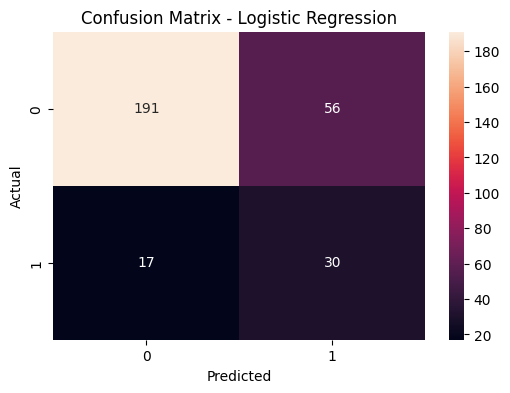

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = log_model.predict(X_test)

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Observation



*   The confusion matrix shows the number of correct and incorrect predictions made by the Logistic Regression model.


*   Most employees were classified correctly, indicating good overall model performance.
*   A small number of employee attrition cases were misclassified.


*   The model provides reliable predictions and can help HR identify employees who are at risk of leaving the company.



Feature Importance Analysis

This section identifies the top 10 most important features influencing employee attrition. Understanding feature importance helps HR identify the key factors responsible for employees leaving the company.

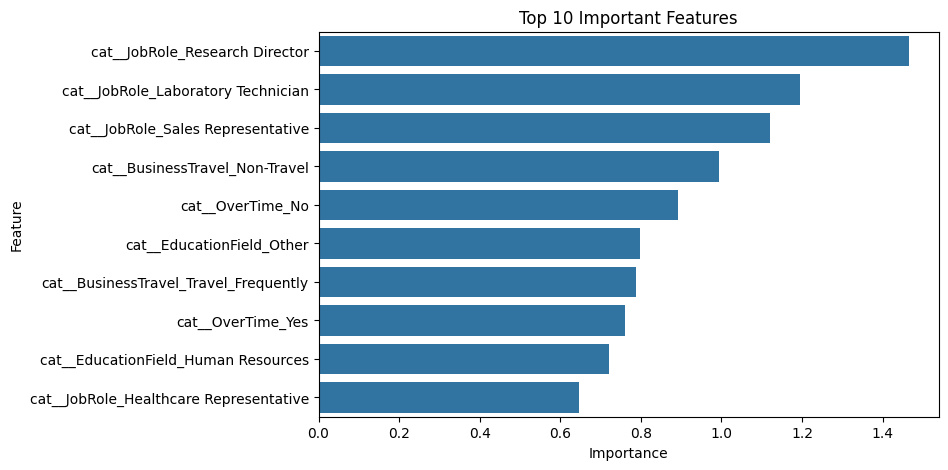

,Feature,Importance
43,cat__JobRole_Research Director,1.465683
40,cat__JobRole_Laboratory Technician,1.194333
46,cat__JobRole_Sales Representative,1.120617
24,cat__BusinessTravel_Non-Travel,0.993885
50,cat__OverTime_No,0.892809
34,cat__EducationField_Other,0.798108
25,cat__BusinessTravel_Travel_Frequently,0.787566
51,cat__OverTime_Yes,0.761522
30,cat__EducationField_Human Resources,0.721129
38,cat__JobRole_Healthcare Representative,0.647202


In [ ]:
feature_names = preprocessor.get_feature_names_out()

coef = abs(log_model.named_steps['model'].coef_[0])

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coef
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

top10 = importance_df.head(10)

plt.figure(figsize=(8,5))
sns.barplot(
    x='Importance',
    y='Feature',
    data=top10
)

plt.title("Top 10 Important Features")
plt.show()

top10

Observation



*   The feature importance analysis highlights the top 10 factors influencing employee attrition.

*   Job Role, Business Travel, OverTime, and Education Field are among the most important features.


*   Employees working in roles such as Research Director, Laboratory Technician, and Sales Representative have a stronger impact on attrition prediction.
*   These insights can help HR focus on improving employee satisfaction, workload management, and retention strategies.

7.HR Insights & Recommendations:

1. Monthly Income, Work-Life Balance, and Job Satisfaction were among the strongest factors influencing employee attrition.

2. Research & Development and Sales departments should be prioritized for retention efforts due to higher employee exits.

3. Salary alone does not explain attrition. Work-life balance, job satisfaction, and career growth opportunities also play significant roles.

4. HR should conduct regular employee satisfaction surveys and provide targeted retention programs for high-risk employees.

5. New employees should receive stronger onboarding and mentoring support because attrition is higher during the early years of employment.

Limitation:
This model is based on historical employee data and may not capture future organizational changes or personal reasons for employee resignation.

Final Conclusion

This project successfully analyzed employee attrition using machine learning techniques. The dataset was cleaned, preprocessed, and explored using various visualizations. Three machine learning models were trained and evaluated. Among all the models, Logistic Regression achieved the best performance with a ROC-AUC Score of 0.706. The project identified important factors such as Job Role, Monthly Income, Work-Life Balance, Business Travel, OverTime, and Years at Company that influence employee attrition. These insights can help HR teams improve employee retention and make better organizational decisions.

**Thank You**

Thank you for reviewing my project.

**Prepared by**: Vaishnavi Vaishnav

**Internship**: XYlofy AI

**Week**: 2